In [9]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.interpolate import interp1d
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [11]:
def get_fred_rates(api_key):
    fred_series = {
        'GS1': '1Y',
        'GS2': '2Y',
        'GS3': '3Y',
        'GS5': '5Y',
        'GS7': '7Y',
        'GS10': '10Y',
    }#spot
        
    if api_key:
    
        from fredapi import Fred
        fred = Fred(api_key=api_key)
        
        df = pd.DataFrame()
        for code, name in fred_series.items():
            data = fred.get_series(code)
            if not data.empty:
                df[name] = data
        
    return df

In [13]:
#Step 1: get the data, check and clean
rates = get_fred_rates('7de2d88d053d5772a2dde00bd4a5e100')
rates.describe()

,1Y,2Y,3Y,5Y,7Y,10Y
count,875.000000,597.00000,875.00000,875.000000,680.000000,875.000000
mean,4.632640,4.96660,4.99992,5.231109,5.817941,5.529954
std,3.242311,3.67264,3.14139,3.035563,3.194567,2.874350
min,0.050000,0.12000,0.16000,0.270000,0.460000,0.620000
25%,2.250000,1.71000,2.69500,2.955000,3.240000,3.550000
50%,4.390000,4.66000,4.54000,4.690000,5.855000,4.730000
75%,6.270000,7.13000,6.81000,6.980000,7.755000,7.330000
max,16.720000,16.46000,16.22000,15.930000,15.650000,15.320000


In [14]:
rates

,1Y,2Y,3Y,5Y,7Y,10Y
1953-04-01,2.36,NaN,2.51,2.62,NaN,2.83
1953-05-01,2.48,NaN,2.72,2.87,NaN,3.05
1953-06-01,2.45,NaN,2.74,2.94,NaN,3.11
1953-07-01,2.38,NaN,2.62,2.75,NaN,2.93
1953-08-01,2.28,NaN,2.58,2.80,NaN,2.95
...,...,...,...,...,...,...
2025-10-01,3.61,3.52,3.53,3.65,3.83,4.06
2025-11-01,3.66,3.55,3.56,3.67,3.86,4.09
2025-12-01,3.54,3.50,3.55,3.70,3.90,4.14
2026-01-01,3.51,3.54,3.61,3.78,3.99,4.21


<Axes: >

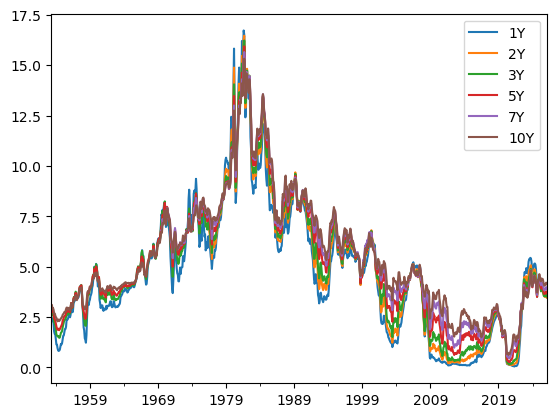

In [15]:
rates.plot()

<Axes: >

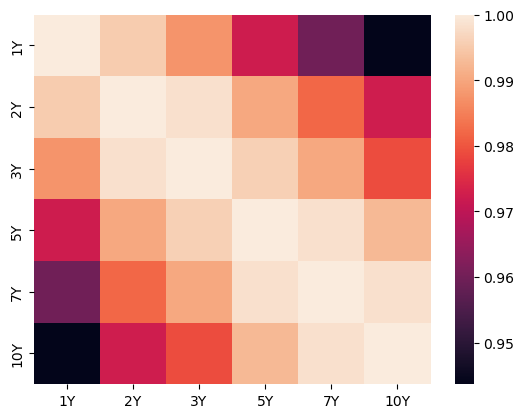

In [19]:
import seaborn as sns
sns.heatmap(rates.corr())
#Based on historical data, there are many missing values for the 2Y and 7Y maturities. The 1Y, 3Y, 5Y, and 10Y maturities show similar trends and movements to these two maturities and have high correlations with them.

In [21]:
rates.isna().sum()

1Y       0
2Y     278
3Y       0
5Y       0
7Y     195
10Y      0
dtype: int64

In [23]:
# interpolate the missing value of 2Y and 7Y
rates['2Y'] = rates.apply(
    lambda row: row['2Y'] if not pd.isna(row['2Y'])
                          else(row['1Y']+row['3Y'])/2,
                          axis=1
)
rates['7Y'] = rates.apply(
    lambda row: row['7Y'] if not pd.isna(row['7Y'])
                          else (row['5Y']* 0.4 +row['10Y']*0.6),#0.4 = (7-5)/(10-5) time weighted
    axis=1
)

In [25]:
rates

,1Y,2Y,3Y,5Y,7Y,10Y
1953-04-01,2.36,2.435,2.51,2.62,2.746,2.83
1953-05-01,2.48,2.600,2.72,2.87,2.978,3.05
1953-06-01,2.45,2.595,2.74,2.94,3.042,3.11
1953-07-01,2.38,2.500,2.62,2.75,2.858,2.93
1953-08-01,2.28,2.430,2.58,2.80,2.890,2.95
...,...,...,...,...,...,...
2025-10-01,3.61,3.520,3.53,3.65,3.830,4.06
2025-11-01,3.66,3.550,3.56,3.67,3.860,4.09
2025-12-01,3.54,3.500,3.55,3.70,3.900,4.14
2026-01-01,3.51,3.540,3.61,3.78,3.990,4.21


In [27]:
rates.describe()

,1Y,2Y,3Y,5Y,7Y,10Y
count,875.000000,875.000000,875.00000,875.000000,875.000000,875.000000
mean,4.632640,4.850229,4.99992,5.231109,5.406656,5.529954
std,3.242311,3.211388,3.14139,3.035563,2.956281,2.874350
min,0.050000,0.120000,0.16000,0.270000,0.460000,0.620000
25%,2.250000,2.530000,2.69500,2.955000,3.265000,3.550000
50%,4.390000,4.500000,4.54000,4.690000,4.750000,4.730000
75%,6.270000,6.650000,6.81000,6.980000,7.165000,7.330000
max,16.720000,16.460000,16.22000,15.930000,15.650000,15.320000


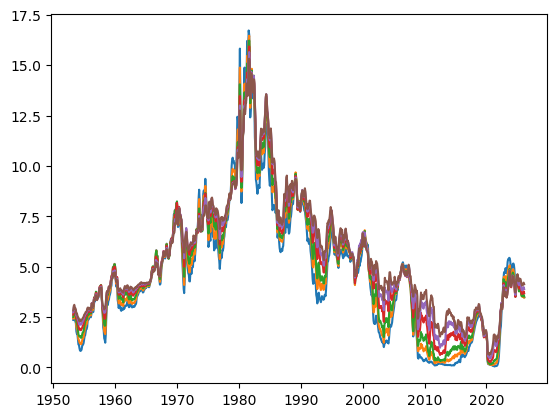

In [29]:
plt.plot(rates)

In [31]:
#Step 2 : calculate monthly change
rates_change_m = rates.diff().dropna()
rates_change_m = rates
rates_change_m

,1Y,2Y,3Y,5Y,7Y,10Y
1953-04-01,2.36,2.435,2.51,2.62,2.746,2.83
1953-05-01,2.48,2.600,2.72,2.87,2.978,3.05
1953-06-01,2.45,2.595,2.74,2.94,3.042,3.11
1953-07-01,2.38,2.500,2.62,2.75,2.858,2.93
1953-08-01,2.28,2.430,2.58,2.80,2.890,2.95
...,...,...,...,...,...,...
2025-10-01,3.61,3.520,3.53,3.65,3.830,4.06
2025-11-01,3.66,3.550,3.56,3.67,3.860,4.09
2025-12-01,3.54,3.500,3.55,3.70,3.900,4.14
2026-01-01,3.51,3.540,3.61,3.78,3.990,4.21


In [33]:
# Step 3: Standardize
scaler = StandardScaler()
X = scaler.fit_transform(rates_change_m)
X

array([[-0.70133312, -0.75251257, -0.79307057, -0.86066459, -0.9005158 ,
        -0.93986419],
       [-0.66430131, -0.70110353, -0.72618295, -0.77826045, -0.82199394,
        -0.86328137],
       [-0.67355926, -0.70266138, -0.7198127 , -0.75518729, -0.80033273,
        -0.84239514],
       ...,
       [-0.33718698, -0.4206906 , -0.4618176 , -0.50467872, -0.50993722,
        -0.48384829],
       [-0.34644493, -0.40822781, -0.44270685, -0.47830939, -0.47947615,
        -0.45948103],
       [-0.35570289, -0.4300377 , -0.47137298, -0.51127105, -0.51332179,
        -0.48732933]])

# Method 1: PCA is implemented using the sklearn library on standardized yield changes.

In [36]:
# Apply PCA
pca = PCA()
pca.fit(X)

#1. explained variance(eigenvalues)
explained_var = np.round(pca.explained_variance_ratio_ , 3)
explained_var
#retain the first three principal components, which together explain almost all of the total variation in monthly yield changes.

array([0.986, 0.014, 0.001, 0.   , 0.   , 0.   ])

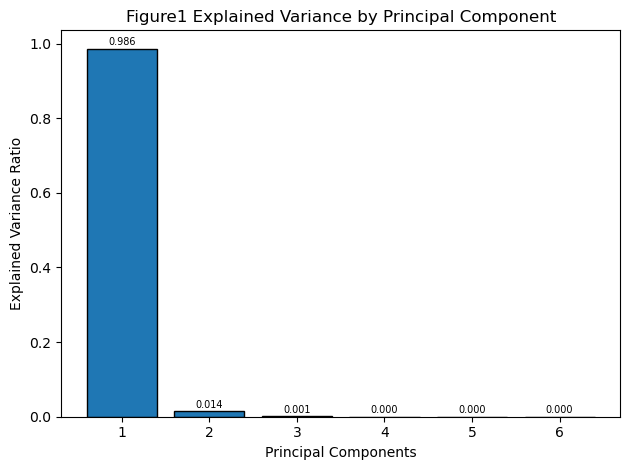

In [38]:
plt.bar(range(1,7), explained_var,edgecolor='black')
plt.xlabel('Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.title('Figure1 Explained Variance by Principal Component')
for i, v in enumerate(explained_var, start=1):
    plt.text(i, v+0.01, f"{v:.3f}", ha='center', fontsize=7)
# save fig
plt.tight_layout()
plt.savefig('Figure1 scree_plot.png', dpi=300, bbox_inches='tight')

In [39]:
#2. loadings
loadings = pd.DataFrame(
    pca.components_.T,
    index=rates_change_m.columns,
    columns=[f"PC{i+1}" for i in range(pca.components_.shape[0])]
)

loadings.iloc[:, :3]

,PC1,PC2,PC3
1Y,0.404240,0.631191,0.553304
2Y,0.409267,0.334267,-0.174293
3Y,0.410650,0.134258,-0.527182
5Y,0.410572,-0.171432,-0.348094
7Y,0.408778,-0.378042,-0.004040
10Y,0.405940,-0.547297,0.514168


The table above reports the loadings of the first three principal components(eigenvectors). In PCA, these loadings correspond to the eigenvectors of the covariance (or correlation) matrix. Each column represents one principal component, while each row corresponds to a maturity of the Treasury yield curve.

Geometrically, each principal component can be viewed as a new axis in the transformed coordinate system. 
The loadings describe the direction of this axis by showing how each maturity contributes to it.

For example, the first principal component can be written as

PC1 = 0.40 · 1Y + 0.41 · 2Y + 0.41 · 3Y + 0.41 · 5Y + 0.41 · 7Y + 0.41 · 10Y

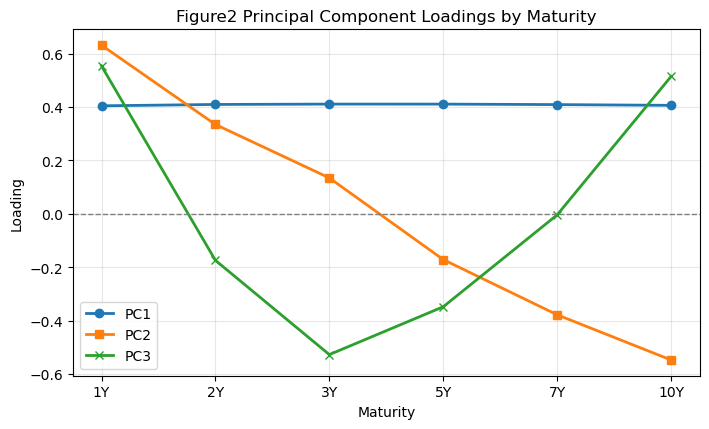

In [42]:
plt.figure(figsize=(7,4))
PC1 = loadings.iloc[:, :1]
PC2 = loadings.iloc[:, 1:2]
PC3 = loadings.iloc[:, 2:3]
plt.plot(PC1,label='PC1',marker='o',linewidth=2)
plt.plot(PC2,label='PC2',marker='s',linewidth=2)
plt.plot(PC3,label='PC3',marker='x',linewidth=2)
plt.axhline(0,color='grey',linestyle='--',linewidth=1)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.xlabel('Maturity')
plt.ylabel('Loading')
plt.title('Figure2 Principal Component Loadings by Maturity')
plt.savefig('Figure2 PC_loadings_by_maturity.png', dpi=300, bbox_inches='tight')

## Interpretation of Principal Component Loadings
- PC1
The first principal component (PC1) exhibits nearly identical positive loadings across all maturities. This pattern indicates that all yields move in the same direction when this factor changes. Therefore, PC1 represents a level factor, capturing parallel shifts in the yield curve. When the level factor increases, interest rates across short-, medium-, and long-term maturities rise simultaneously.

- PC2
The second principal component (PC2) shows positive loadings for short-term maturities and negative loadings for long-term maturities. This opposite movement between the short end and the long end of the curve reflects changes in the steepness of the yield curve. As a result, PC2 can be interpreted as a slope factor, representing steepening or flattening of the yield curve.

- PC3
The third principal component (PC3) exhibits a curvature pattern. Loadings are positive at the short and long ends of the curve but negative for medium-term maturities. This indicates that medium-term yields move differently relative to both short- and long-term yields. Consequently, PC3 captures curvature changes in the yield curve, often associated with hump-shaped movements.

Overall, the loading patterns confirm the well-known three-factor representation of the yield curve: level, slope, and curvature.

In [45]:
# 3. Data Projection
scores = pd.DataFrame(
    pca.transform(X),
    index=rates_change_m.index,
    columns=[f"PC{i+1}" for i in range(pca.components_.shape[0])]
)

scores[['PC1', 'PC2','PC3']].head() #projection of data onto PC axes

,PC1,PC2,PC3
1953-04-01,-2.020165,0.201672,-0.018818
1953-05-01,-1.859669,0.165486,-0.032176
1953-06-01,-1.834627,0.136402,-0.037765
1953-07-01,-1.947774,0.176313,-0.034574
1953-08-01,-1.960387,0.137104,-0.043332


Each row corresponds to a specific date, and the three values represent the coordinates of that observation in the PCA factor space:
- PC1: level factor
- PC2: slope factor
- PC3: curvature factor
 
[-2.02,0.20,-0.02]means that at that time point the yield curve movement can be described by a combination of:
- a negative level shift
- a small positive slope change
- a very small curvature change

Thus, the original 6-dimensional yield data is now represented by three factors.

## Data projection
Data projection transforms the standardized yield changes into the PCA coordinate system. Each observation is represented by its scores on the principal components, which measure the strength of level, slope, and curvature movements at each point in time.

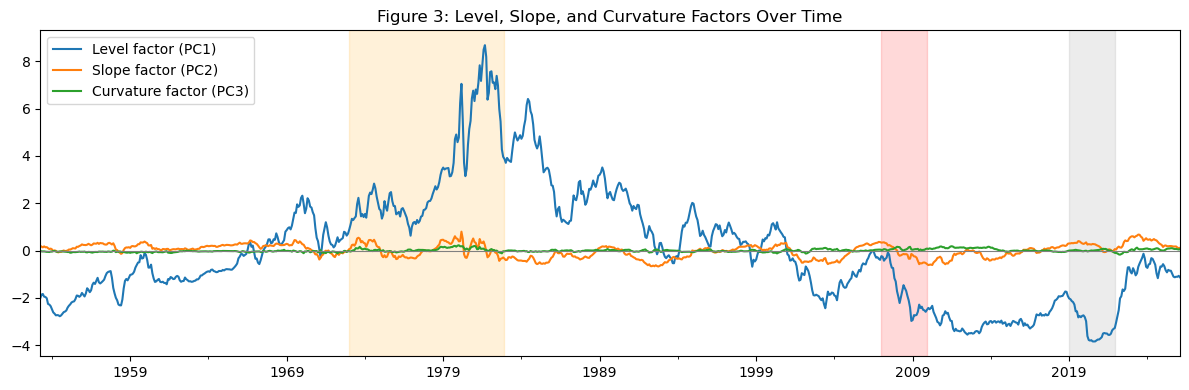

In [48]:
import matplotlib.pyplot as plt

scores[['PC1', 'PC2','PC3']].plot(
    figsize=(12, 4),
    title='Figure 3: Level, Slope, and Curvature Factors Over Time',
)

plt.axhline(0, color='grey', linewidth=0.8)

# 1973–1982 Oil Shock period (First Oil Shock (1973–1974), Second Oil Shock (1979–1980))
plt.axvspan('1973-01-01','1982-12-31',
           color='orange',alpha=0.15,label='Oil Shock Period')

# 2007–2009 Global Financial Crisis
plt.axvspan('2007-01-01', '2009-12-31',
            color='red', alpha=0.15, label='2008 Financial Crisis')

# 2019–2021 COVID-19 period
plt.axvspan('2019-01-01', '2021-12-31',
            color='gray', alpha=0.15, label='COVID-19 Period')

plt.legend(['Level factor (PC1)', 'Slope factor (PC2)','Curvature factor (PC3)'])
plt.tight_layout()
plt.savefig('Figure3 Level, Slope and Curvature Factor Over Time', dpi=300, bbox_inches='tight')
plt.show()

## Principal Factors over time analysis
Figure 3 plots the time series of the level (PC1), slope (PC2), and curvature (PC3) factors. 

The level factor shows much larger fluctuations than the other components, indicating that parallel shifts across maturities drive most movements in Treasury yields. The slope factor captures changes in the steepness of the yield curve, reflecting differences between short-term and long-term interest rate movements. Meanwhile, the curvature factor represents changes in the relative movement of medium-term yields compared with the short and long ends of the curve.

Significant movements in the level factor can be observed during periods of major macroeconomic stress. In particular, the late 1970s and early 1980s correspond to a period of persistent high inflation, oil price shocks, and strong monetary tightening by the Federal Reserve. Additional spikes appear during the 2007–2009 global financial crisis and the COVID-19 pandemic, when large economic shocks caused synchronized movements in Treasury yields across maturities.

# Method 2: PCA using Eigenvalue Decomposition

In [105]:
x_standard = pd.DataFrame(X,index=rates_change_m.index,columns=rates_change_m.columns)
x_standard

,1Y,2Y,3Y,5Y,7Y,10Y
1953-04-01,-0.701333,-0.752513,-0.793071,-0.860665,-0.900516,-0.939864
1953-05-01,-0.664301,-0.701104,-0.726183,-0.778260,-0.821994,-0.863281
1953-06-01,-0.673559,-0.702661,-0.719813,-0.755187,-0.800333,-0.842395
1953-07-01,-0.695161,-0.732261,-0.758034,-0.817814,-0.862609,-0.905054
1953-08-01,-0.726021,-0.754070,-0.770775,-0.801334,-0.851778,-0.898092
...,...,...,...,...,...,...
2025-10-01,-0.315585,-0.414459,-0.468188,-0.521160,-0.533629,-0.511697
2025-11-01,-0.300155,-0.405112,-0.458632,-0.514567,-0.523475,-0.501253
2025-12-01,-0.337187,-0.420691,-0.461818,-0.504679,-0.509937,-0.483848
2026-01-01,-0.346445,-0.408228,-0.442707,-0.478309,-0.479476,-0.459481


<Axes: >

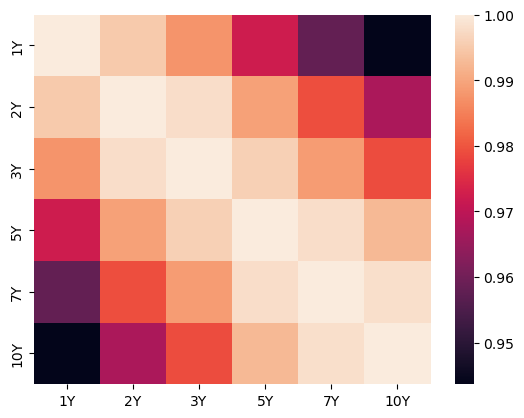

In [107]:
sns.heatmap(x_standard.corr())

In [109]:
mu = rates_change_m.mean()
sigma = rates_change_m.std()
x_standard = (rates_change_m-mu)/sigma
corr_matrix_dt = x_standard.cov()
corr_matrix_dt

,1Y,2Y,3Y,5Y,7Y,10Y
1Y,1.000000,0.995137,0.987514,0.972158,0.958015,0.943641
2Y,0.995137,1.000000,0.998002,0.989317,0.979234,0.967494
3Y,0.987514,0.998002,1.000000,0.995994,0.988678,0.978962
5Y,0.972158,0.989317,0.995994,1.000000,0.997896,0.992590
7Y,0.958015,0.979234,0.988678,0.997896,1.000000,0.998115
10Y,0.943641,0.967494,0.978962,0.992590,0.998115,1.000000


In [111]:
eigenvalues, eigenvectors = np.linalg.eig(corr_matrix_dt)

In [113]:
PC_index = ["PC1","PC2","PC3","PC4","PC5","PC6"]
df_eigval = pd.DataFrame({"Eigenvalues":eigenvalues}, index = PC_index )
df_eigval

,Eigenvalues
PC1,5.914449
PC2,0.081009
PC3,0.003934
PC4,0.000344
PC5,0.000089
PC6,0.000175


In [115]:
# Work out explained proportion 
df_eigval["Explained proportion"] = df_eigval["Eigenvalues"] / np.sum(df_eigval["Eigenvalues"])
#Format as row number
df_eigval.style.format({"Explained proportion": '{.2f%}'})
df_eigval

,Eigenvalues,Explained proportion
PC1,5.914449,0.985741
PC2,0.081009,0.013502
PC3,0.003934,0.000656
PC4,0.000344,0.000057
PC5,0.000089,0.000015
PC6,0.000175,0.000029


In [117]:
eigenvectors_dt = pd.DataFrame(eigenvectors, columns = ["PC1","PC2","PC3","PC4","PC5","PC6"], index = corr_matrix_dt.columns )
eigenvectors_dt

,PC1,PC2,PC3,PC4,PC5,PC6
1Y,0.404240,-0.631191,0.553304,0.330780,-0.129029,0.077325
2Y,0.409267,-0.334267,-0.174293,-0.579232,0.453734,-0.386009
3Y,0.410650,-0.134258,-0.527182,-0.195905,-0.575699,0.406955
5Y,0.410572,0.171432,-0.348094,0.565679,0.549979,0.241665
7Y,0.408778,0.378042,-0.004040,0.247160,-0.372042,-0.700332
10Y,0.405940,0.547297,0.514168,-0.368259,0.071803,0.361302


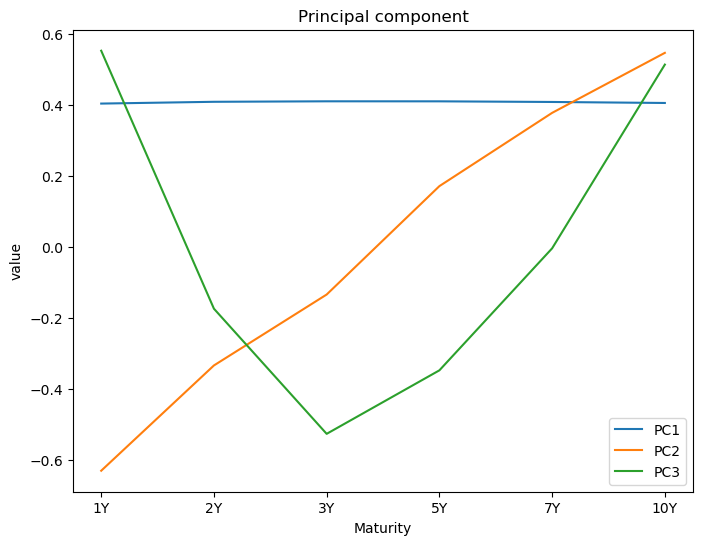

In [123]:
plt.figure(figsize=(8, 6))
for t in ["PC1","PC2","PC3"]:
    PC = eigenvectors_dt[t]
    display(plt.plot(PC, label = t))
    plt.xlabel("Maturity")
    plt.ylabel("value")
    plt.legend()
    plt.title("Principal component")

In [53]:
# Rolling Window Stability testing
window = 60  
rolling_explained = []
rolling_dates = []

for i in range(window, len(rates_change_m)):
    window_data = rates_change_m.iloc[i-window:i]
    
    # standardize each window
    X_win = StandardScaler().fit_transform(window_data)
    
    # PCA
    pca_win = PCA(n_components=3)
    pca_win.fit(X_win)
    
    rolling_explained.append(pca_win.explained_variance_ratio_)
    rolling_dates.append(rates_change_m.index[i])
    
rolling_explained = np.array(rolling_explained)

rolling_df = pd.DataFrame(
    rolling_explained,
    index=rolling_dates,
    columns=['PC1', 'PC2','PC3']
)


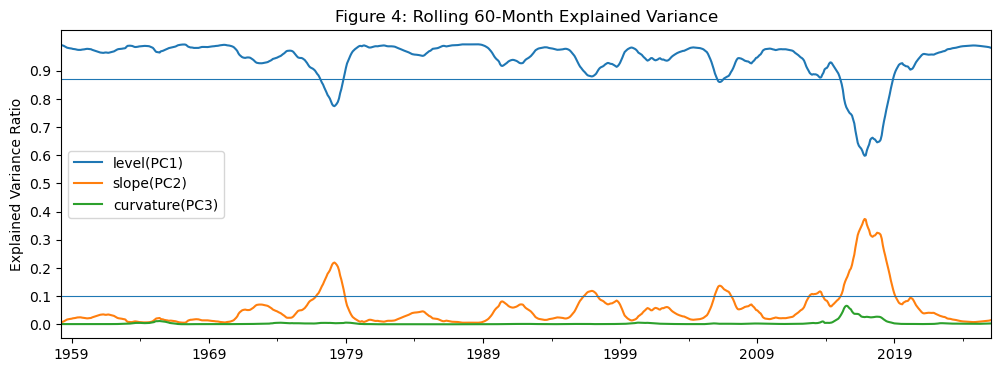

In [57]:
rolling_df.plot(
    figsize=(12,4),
    title='Figure 4: Rolling 60-Month Explained Variance'
)

plt.ylabel('Explained Variance Ratio')
plt.legend(['level(PC1)','slope(PC2)','curvature(PC3)'])
plt.gca().set_yticks(np.arange(0, 1.0, 0.1)) 
plt.axhline(0.87, linewidth=0.8)
plt.axhline(0.10, linewidth=0.8)
plt.savefig('Figure4 Rolling 60-Month Explained Variance.png')
plt.show()

## Rolling Window Analysis Interpretation
Figure 4 presents the explained variance ratios of the first three principal components estimated using a rolling 60-month window. The level factor (PC1) consistently explains the majority of yield curve variation, remaining close to 90% throughout most of the sample. In contrast, the slope factor (PC2) accounts for a smaller share of the variance, typically around 10%, while the curvature factor (PC3) contributes only a minimal portion.

Although the relative importance of the factors fluctuates during periods of market stress—most notably around the global financial crisis—the dominance of the level factor remains stable over time. Overall, the results suggest that the three-factor representation of the yield curve is relatively stable.

In [ ]:
#Reconstruction Test

# Use the first three principal component scores(Time x Factor)
pcs = scores[['PC1','PC2','PC3']].values

# PCA loadings corresponding to the first three components(Factor x Maturity)
loadings_3 = pca.components_[:3]

# Reconstruct the standardized data using PC scores and loadings(Time x Maturity)
X_reconstructed = np.dot(pcs, loadings_3)

# Convert the reconstructed array back to a DataFrame
reconstructed_df = pd.DataFrame(
    X_reconstructed,
    index=rates_change_m.index,
    columns=rates_change_m.columns
)

# If the data were standardized earlier, apply inverse transformation
# to convert the reconstructed data back to the original scale
reconstructed_original_scale = pd.DataFrame(
    scaler.inverse_transform(reconstructed_df),
    index=rates_change_m.index,
    columns=rates_change_m.columns
)

In [99]:
X_reconstructed

array([[-0.69975064, -0.75609561, -0.79258454, -0.85744602, -0.9019645 ,
        -0.94011577],
       [-0.66510278, -0.70017748, -0.72449323, -0.78069766, -0.82262331,
        -0.86202744],
       [-0.67643001, -0.69867621, -0.71516782, -0.7634844 , -0.80136888,
        -0.83881786],
       ...,
       [-0.33484202, -0.42167783, -0.46982619, -0.49846888, -0.50269844,
        -0.49065671],
       [-0.34351604, -0.41139103, -0.44879293, -0.4712644 , -0.47455073,
        -0.46513706],
       [-0.3523531 , -0.43356923, -0.47831049, -0.50389863, -0.50670995,
        -0.4942012 ]])

In [97]:
reconstructed_df

,1Y,2Y,3Y,5Y,7Y,10Y
1953-04-01,-0.699751,-0.756096,-0.792585,-0.857446,-0.901964,-0.940116
1953-05-01,-0.665103,-0.700177,-0.724493,-0.780698,-0.822623,-0.862027
1953-06-01,-0.676430,-0.698676,-0.715168,-0.763484,-0.801369,-0.838818
1953-07-01,-0.695211,-0.732199,-0.757956,-0.817893,-0.862722,-0.904952
1953-08-01,-0.729904,-0.748941,-0.763782,-0.813301,-0.853020,-0.893116
...,...,...,...,...,...,...
2025-10-01,-0.312946,-0.416490,-0.475067,-0.515485,-0.526360,-0.518379
2025-11-01,-0.297907,-0.405921,-0.466887,-0.507487,-0.517435,-0.507570
2025-12-01,-0.334842,-0.421678,-0.469826,-0.498469,-0.502698,-0.490657
2026-01-01,-0.343516,-0.411391,-0.448793,-0.471264,-0.474551,-0.465137


In [101]:
reconstructed_original_scale

,1Y,2Y,3Y,5Y,7Y,10Y
1953-04-01,2.365128,2.423500,2.511526,2.629765,2.741720,2.829277
1953-05-01,2.477403,2.602972,2.725305,2.862606,2.976140,3.053602
1953-06-01,2.440697,2.607791,2.754583,2.914828,3.038939,3.120276
1953-07-01,2.379837,2.500198,2.620247,2.749763,2.857664,2.930293
1953-08-01,2.267416,2.446464,2.601954,2.763694,2.886331,2.964294
...,...,...,...,...,...,...
2025-10-01,3.618553,3.513483,3.508402,3.667217,3.851479,4.040803
2025-11-01,3.667286,3.547403,3.534083,3.691481,3.877848,4.071854
2025-12-01,3.547599,3.496831,3.524856,3.718840,3.921388,4.120441
2026-01-01,3.519491,3.529847,3.590892,3.801373,4.004553,4.193752


In [103]:
# Compute reconstruction error using RMSE (Root Mean Squared Error)
rmse = np.sqrt(((rates_change_m - reconstructed_original_scale) ** 2).mean())

print("Reconstruction RMSE by maturity:")
print(rmse)

Reconstruction RMSE by maturity:
1Y     0.020545
2Y     0.040579
3Y     0.026557
5Y     0.036807
7Y     0.032253
10Y    0.024037
dtype: float64


The results show that the reconstruction errors are very small (around 0.02–0.04 across maturities), indicating that the **three-factor representation (level, slope, and curvature) captures most of the variation in the yield curve movements**.

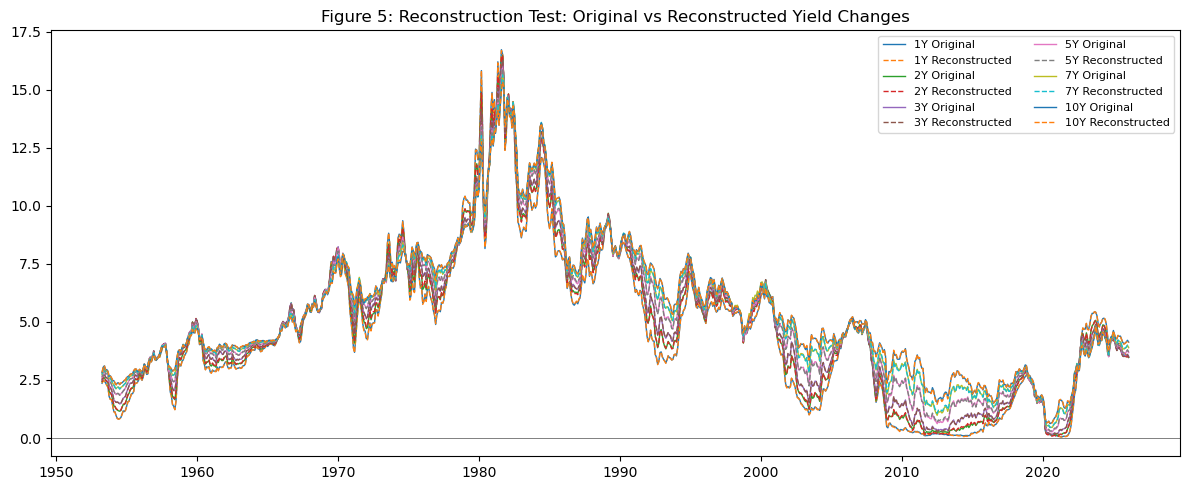

In [93]:
plt.figure(figsize=(12,5))

for maturity in rates_change_m.columns:
    
    # original
    plt.plot(
        rates_change_m.index,
        rates_change_m[maturity],
        linewidth=1,
        label=f'{maturity} Original'
    )
    
    # reconstructed
    plt.plot(
        reconstructed_original_scale.index,
        reconstructed_original_scale[maturity],
        linestyle='--',
        linewidth=1,
        label=f'{maturity} Reconstructed'
    )

plt.axhline(0,color='grey',linewidth=0.7)

plt.title('Figure 5: Reconstruction Test: Original vs Reconstructed Yield Changes')

plt.legend(ncol=2,fontsize=8)

plt.tight_layout()

plt.savefig('Figure5_Reconstruction_All_Maturities.png',dpi=300,bbox_inches='tight')

plt.show()

## Reconstruction Test Interpretation
Figure 5 compares the original and reconstructed yield changes using the first three principal components. The reconstructed series closely tracks the original data across all maturities, indicating that the three-factor representation captures most of the variation in the yield curve. This result further confirms that the level, slope, and curvature factors provide a stable and effective summary of yield curve dynamics.